# Data Cleaning & Preparation

This notebook loads the raw enriched dataset and prepares it for ML training.

## Plan:
1. **Load raw data** — inspect all columns, types, and missing values
2. **Identify columns to drop** — merge keys, duplicates, address fields that served their purpose
3. **Filter rows** — remove non-residential properties, fake transactions, data errors
4. **Clean categories** — fix duplicates, group rare values, standardise casing
5. **Handle missing values** — decide per column: drop rows, impute, or remove feature
6. **Feature engineering** — extract date features, create any new features
7. **Final check** — verify everything is clean, save to parquet for training

In [1]:
# =============================================================================
# SECTION 1: LOAD RAW DATA
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

pd.set_option("display.max_columns", None)

df = pd.read_parquet("Outputs/lr_epc_towns.parquet")

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col} — {df[col].dtype} — {df[col].isna().sum():,} NaN ({df[col].isna().mean()*100:.1f}%)")

Rows: 5,890,089
Columns: 68

Column names:
  1. transaction_id — str — 0 NaN (0.0%)
  2. price — int64 — 0 NaN (0.0%)
  3. date — datetime64[us] — 0 NaN (0.0%)
  4. postcode_x — str — 16,882 NaN (0.3%)
  5. property_type_x — str — 0 NaN (0.0%)
  6. new_build — str — 0 NaN (0.0%)
  7. duration — str — 0 NaN (0.0%)
  8. paon — str — 0 NaN (0.0%)
  9. saon — str — 5,120,784 NaN (86.9%)
  10. street — str — 104,496 NaN (1.8%)
  11. locality — str — 3,633,468 NaN (61.7%)
  12. town — str — 0 NaN (0.0%)
  13. district — str — 0 NaN (0.0%)
  14. county — str — 0 NaN (0.0%)
  15. ppd_category — str — 0 NaN (0.0%)
  16. record_status — str — 0 NaN (0.0%)
  17. postcode_clean — str — 0 NaN (0.0%)
  18. address_key — str — 0 NaN (0.0%)
  19. address1 — str — 1,510,841 NaN (25.7%)
  20. postcode_y — str — 1,510,841 NaN (25.7%)
  21. uprn — float64 — 1,518,329 NaN (25.8%)
  22. total_floor_area — float64 — 1,510,843 NaN (25.7%)
  23. lodgement_date — datetime64[us] — 1,510,841 NaN (25.7%)
  24. cur

## Section 2: Column Analysis - What to Keep, Drop, or Clean

There are 53 columns. Each one is categorised as **KEEP**, **DROP**, or **CLEAN** (keep but needs fixing).

### Land Registry (columns 1-16)

| # | Column | Decision | Reason |
|---|--------|----------|--------|
| 1 | transaction_id | DROP | Unique ID, no predictive value |
| 2 | price | **KEEP** | Target variable |
| 3 | date | **KEEP** | Will extract year and month, then drop |
| 4 | postcode_x | DROP | Merge key, location captured by coordinates |
| 5 | property_type_x | DROP - same as property_type_y | D/S/T/F/O — will remove O (commercial) |
| 6 | new_build | **KEEP** | Y/N binary feature |
| 7 | duration | **KEEP** | Freehold/Leasehold |
| 8 | paon | DROP | House number, not a feature |
| 9 | saon | DROP | Flat number, 87% NaN |
| 10 | street | DROP | Address component |
| 11 | locality | DROP | 62% NaN, location captured by coordinates |
| 12 | town | DROP | Location captured by distance features |
| 13 | district | DROP | Location captured by distance features |
| 14 | county | DROP | Location captured by distance features |
| 15 | ppd_category | REMOVE ROW IF = B AND DROP | Land Registry admin code (A=standard, B=additional) |
| 16 | record_status | DROP | Land Registry internal status |

### EPC Matching (columns 17-20)

| # | Column | Decision | Reason |
|---|--------|----------|--------|
| 17 | postcode_clean | DROP | Merge key (postcode without spaces) |
| 18 | address_key | DROP | Merge key (normalised address for matching) |
| 19 | address1 | DROP | Merge key, 26% NaN (no EPC match) |
| 20 | postcode_y | DROP | EPC postcode, same as postcode_x |

### EPC Features (columns 21-33)

| # | Column | Decision | Reason |
|---|--------|----------|--------|
| 21 | uprn | DROP | ID used to get coordinates, not a feature |
| 22 | total_floor_area | **KEEP** | Strong predictor, 26% NaN = no EPC match |
| 23 | lodgement_date | DROP | When EPC was lodged, not when house sold |
| 24 | current_energy_efficiency | **KEEP** | Numeric efficiency score |
| 25 | current_energy_rating | **KEEP** | A-G categorical rating |
| 26 | number_habitable_rooms | **CLEAN** | 37% NaN, has outliers (97+ rooms) |
| 27 | tenure | **CLEAN** | Casing inconsistency (owner-occupied vs Owner-occupied) |
| 28 | property_type_y | **KEEP** | House/Flat/Bungalow/Maisonette (different from property_type_x) |
| 29 | transaction_type | DROP | 19 categories → reason for the epc cert |
| 30 | construction_age_band | **CLEAN** | 74 categories → 13 (individual years → bands) |
| 31 | built_form | **KEEP** | Detached/Semi/Terrace etc |
| 32 | main_fuel | **CLEAN** | 39 categories → 6 (group similar fuel types) |
| 33 | mains_gas_flag | DROP | 43% NaN, too much missing to be useful |

### Coordinates (columns 34-40)

| # | Column | Decision | Reason |
|---|--------|----------|--------|
| 34 | postcode_merge | DROP | Merge key |
| 35 | PCDS | DROP | Merge key |
| 36 | LAT | DROP | Postcode centroid, less precise than exact |
| 37 | LONG | DROP | Postcode centroid, less precise than exact |
| 38 | exact_lat | **KEEP** | Exact property latitude |
| 39 | exact_lon | **KEEP** | Exact property longitude |
| 40 | has_exact_coords | DROP | Flag column, not a feature |

### Spatial Features (columns 41-53)

| # | Column | Decision | Reason |
|---|--------|----------|--------|
| 41 | dist_primary_km | **KEEP** | Distance to nearest primary school |
| 42 | dist_secondary_km | **KEEP** | Distance to nearest secondary school |
| 43 | dist_rail_km | **KEEP** | Distance to nearest rail station |
| 44 | rail_within_1km | **KEEP** | Rail station density |
| 45 | rail_within_5km | **KEEP** | Rail station density |
| 46 | dist_metro_km | **KEEP** | Distance to nearest metro/underground |
| 47 | metro_within_1km | **KEEP** | Metro station density |
| 48 | dist_bus_km | DROP | Near-zero correlation with price (-0.007) |
| 49 | bus_within_1km | DROP | No predictive signal |
| 50 | dist_airport_km | **KEEP** | Distance to nearest airport |
| 51 | dist_coast_km | **KEEP** | Distance to nearest coastline |
| 52 | dist_town_km | **KEEP** | Distance to nearest major town |
| 53 | nearest_town | DROP | Town name, 112 categories, keeping dist only |

### Comparison Features (from add_comparison_properties.py)

| # | Column | Decision | Reason |
|---|--------|----------|--------|
| 1 | comp1_price | **KEEP** | Price of nearest prior sale — strong predictor. NaN when no comparable |
| 2 | comp1_floor_area | **CLEAN** | Weak alone; derive comp £/m² (price ÷ area) or size-diff vs target, else drop |
| 3 | comp1_distance_km | **KEEP** | How near the comparable is = how relevant it is |
| 4 | comp1_days_ago | **KEEP** | Recency of comparable; supports time adjustment |
| 5 | comp2_price | **KEEP** | Second-nearest prior sale price |
| 6 | comp2_floor_area | **CLEAN** | Same as comp1_floor_area — derive £/m² or drop |
| 7 | comp2_distance_km | **KEEP** | Relevance of second comparable |
| 8 | comp2_days_ago | **KEEP** | Recency of second comparable |
| 9 | comp3_price | **KEEP** | Third-nearest prior sale price |
| 10 | comp3_floor_area | **CLEAN** | Same as comp1_floor_area — derive £/m² or drop |
| 11 | comp3_distance_km | **KEEP** | Relevance of third comparable |
| 12 | comp3_days_ago | **KEEP** | Recency of third comparable |
| 13 | n_comparables | **KEEP** | 0–3 count; local sales-density / confidence signal, encodes the NaN pattern |
| 14 | has_comparables | DROP | Redundant — equals n_comparables > 0 |

In [2]:
# =============================================================================
# IMPORTANT - We are removing rows with certain columns before we drop them. 
# E.g - we are dropping ppd_category = B (those are non standard transactions) before we drop the column
# =============================================================================

"""
print(f"Record status: {df['ppd_category'].value_counts().to_dict()}")
print(df.groupby("ppd_category")["price"].describe())
print(df.groupby("ppd_category")["property_type_x"].value_counts())
dupes = df[df.duplicated(
    subset=["price", "date", "exact_lat", "exact_lon"],
    keep=False
)]
print(dupes["ppd_category"].value_counts())
"""


#Should I drop ppd_category B? - As of now, I am not dropping it. I will keep it for now.
#before = len(df)
#df = df[df["ppd_category"] == "A"]
#print(f"Dropped PPD category B: {before:,} → {len(df):,} (removed {before - len(df):,})")

'\nprint(f"Record status: {df[\'ppd_category\'].value_counts().to_dict()}")\nprint(df.groupby("ppd_category")["price"].describe())\nprint(df.groupby("ppd_category")["property_type_x"].value_counts())\ndupes = df[df.duplicated(\n    subset=["price", "date", "exact_lat", "exact_lon"],\n    keep=False\n)]\nprint(dupes["ppd_category"].value_counts())\n'

In [3]:
df["postcode_merged"] = df["postcode_x"].fillna(df["postcode_y"])

In [4]:
drop_columns = [
    # Land Registry — IDs and address fields
    "transaction_id", "postcode_x", "paon", "saon", "street", 
    "locality", "town", "district", "county", 
    "record_status", "ppd_category"
    
    # EPC matching — merge keys
    "postcode_clean", "address_key", "address1", "postcode_y",
    
    # EPC — ID and date
    "uprn", "lodgement_date", "IMD20IND",
    
    # EPC — too much missing
    "mains_gas_flag", 

    # EPC — dropped when investigating and cleaning. Its not needed. 
    "property_type_y", "transaction_type",
    
    # property_type and postcode were cleared accidentally when joining data.
    "property_type","postcode",

    # Coordinates — merge keys and less precise fallbacks
    "postcode_merge", "PCDS", "LAT", "LONG", "has_exact_coords",
    
    # Spatial — no predictive signal
    "dist_bus_km", "bus_within_1km",
    
    # Town name — keeping distance only
    "nearest_town",

    # comparable features
    "n_comparables",
]

print(f"Dropping {len(drop_columns)} columns")
print(f"Keeping {len(df.columns) - len(drop_columns)} columns")

before_cols = len(df.columns)
df = df.drop(columns=drop_columns, errors="ignore")
print(f"Dropped {before_cols - len(df.columns)} columns: {before_cols} → {len(df.columns)}")


Dropping 31 columns
Keeping 38 columns


Dropped 28 columns: 69 → 41


In [5]:
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col} — {df[col].dtype} — {df[col].isna().sum():,} NaN ({df[col].isna().mean()*100:.1f}%)")

Rows: 5,890,089
Columns: 41

Column names:
  1. price — int64 — 0 NaN (0.0%)
  2. date — datetime64[us] — 0 NaN (0.0%)
  3. property_type_x — str — 0 NaN (0.0%)
  4. new_build — str — 0 NaN (0.0%)
  5. duration — str — 0 NaN (0.0%)
  6. ppd_category — str — 0 NaN (0.0%)
  7. postcode_clean — str — 0 NaN (0.0%)
  8. total_floor_area — float64 — 1,510,843 NaN (25.7%)
  9. current_energy_efficiency — float64 — 1,510,841 NaN (25.7%)
  10. current_energy_rating — str — 1,510,841 NaN (25.7%)
  11. number_habitable_rooms — float64 — 2,188,951 NaN (37.2%)
  12. tenure — str — 1,578,450 NaN (26.8%)
  13. construction_age_band — str — 1,510,844 NaN (25.7%)
  14. built_form — str — 1,530,033 NaN (26.0%)
  15. main_fuel — str — 1,521,398 NaN (25.8%)
  16. exact_lat — float64 — 1,518,496 NaN (25.8%)
  17. exact_lon — float64 — 1,518,496 NaN (25.8%)
  18. comp1_price — float64 — 1,518,864 NaN (25.8%)
  19. comp1_floor_area — float64 — 1,519,199 NaN (25.8%)
  20. comp1_distance_km — float64 — 1,518,8

## Section 3: Row Filtering

Before removing any rows, each filter is analysed to understand what we're losing and why. 

Filters to investigate:
1. **No EPC match** - rows without house details (floor area, rooms, energy rating)
2. **No coordinates** -rows without exact property location
3. **Commercial properties** - type O (offices, retail, not residential)
4. **Low prices + High prices** - £1 transfers and non-market transactions - extreme outliers (£5M+)
5. **Floor area errors** - zero, impossibly small, or impossibly larg
6. **Duplicate Transactions** - make sure there is no repeated rows
7. **Energy Efficiency Outliers** - rows with extreme or incorrect values. 

### No EPC match

In [6]:

no_epc = df[df["total_floor_area"].isna()]
has_epc = df[df["total_floor_area"].notna()]

print(f"No EPC match: {len(no_epc):,} ({len(no_epc)/len(df)*100:.1f}%)")
print(f"Has EPC match: {len(has_epc):,} ({len(has_epc)/len(df)*100:.1f}%)")

print(f"\nWhat we lose without EPC:")
print(f"  These rows have NO: floor area, rooms, energy rating, tenure, built form")
print(f"  They only have: price, property type, date, and spatial features")

print(f"\nPrice comparison:")
print(f"  With EPC    — median: £{has_epc['price'].median():,.0f}, mean: £{has_epc['price'].mean():,.0f}")
print(f"  Without EPC — median: £{no_epc['price'].median():,.0f}, mean: £{no_epc['price'].mean():,.0f}")

print(f"\nDate range without EPC:")
print(f"  {no_epc['date'].min()} to {no_epc['date'].max()}")

# Are they concentrated in certain years?
print(f"\nNo-EPC sales by year:")
print(no_epc["date"].dt.year.value_counts().sort_index())

# Are certain property types more likely to have no EPC?
print(f"\nProperty type — no EPC vs has EPC:")
print(f"  No EPC:  {no_epc['property_type_x'].value_counts().to_dict()}")
print(f"  Has EPC: {has_epc['property_type_x'].value_counts().to_dict()}")

# Geographic — are they spread evenly or concentrated somewhere?
print(f"\nHave coordinates? (can still check location)")
print(f"  No EPC with coords: {no_epc['dist_town_km'].notna().sum():,}")
print(f"  No EPC without coords: {no_epc['dist_town_km'].isna().sum():,}")

# New builds — should always have EPC since they need one by law
print(f"\nNew builds without EPC: {no_epc[no_epc['new_build'] == 'Y'].shape[0]:,}")
print(f"  (New builds require EPC by law)")


No EPC match: 1,510,843 (25.7%)
Has EPC match: 4,379,246 (74.3%)

What we lose without EPC:
  These rows have NO: floor area, rooms, energy rating, tenure, built form
  They only have: price, property type, date, and spatial features

Price comparison:
  With EPC    — median: £266,000, mean: £332,785
  Without EPC — median: £300,000, mean: £572,666

Date range without EPC:
  2020-01-01 00:00:00 to 2025-12-31 00:00:00

No-EPC sales by year:
date
2020    267008
2021    354273
2022    278838
2023    214695
2024    219775
2025    176254
Name: count, dtype: int64

Property type — no EPC vs has EPC:
  No EPC:  {'F': 697501, 'D': 272906, 'O': 256431, 'T': 147298, 'S': 136707}
  Has EPC: {'T': 1444504, 'S': 1431093, 'D': 1095608, 'F': 336559, 'O': 71482}

Have coordinates? (can still check location)
  No EPC with coords: 1,487,827
  No EPC without coords: 23,016

New builds without EPC: 207,009
  (New builds require EPC by law)


In [ ]:
before = len(df)
df = df[df["total_floor_area"].notna()]
print(f"Dropped no EPC: {before:,} → {len(df):,} (removed {before - len(df):,})")

### No coordinates

In [8]:
no_coords = df[df["exact_lat"].isna()]
has_coords = df[df["exact_lat"].notna()]

print(f"No exact coordinates: {len(no_coords):,} ({len(no_coords)/len(df)*100:.1f}%)")
print(f"Has exact coordinates: {len(has_coords):,} ({len(has_coords)/len(df)*100:.1f}%)")


No exact coordinates: 7,655 (0.2%)
Has exact coordinates: 4,371,591 (99.8%)


In [9]:
before = len(df)
df = df[df["exact_lat"].notna()]
print(f"Dropped no coordinates: {before:,} → {len(df):,} (removed {before - len(df):,})")

Dropped no coordinates: 4,379,246 → 4,371,591 (removed 7,655)


### Commercial properties

In [10]:
before = len(df)
df = df[df["property_type_x"] != "O"]
print(f"Dropped type O: {before:,} → {len(df):,} (removed {before - len(df):,})")

Dropped type O: 4,371,591 → 4,300,482 (removed 71,109)


### Low prices + High prices

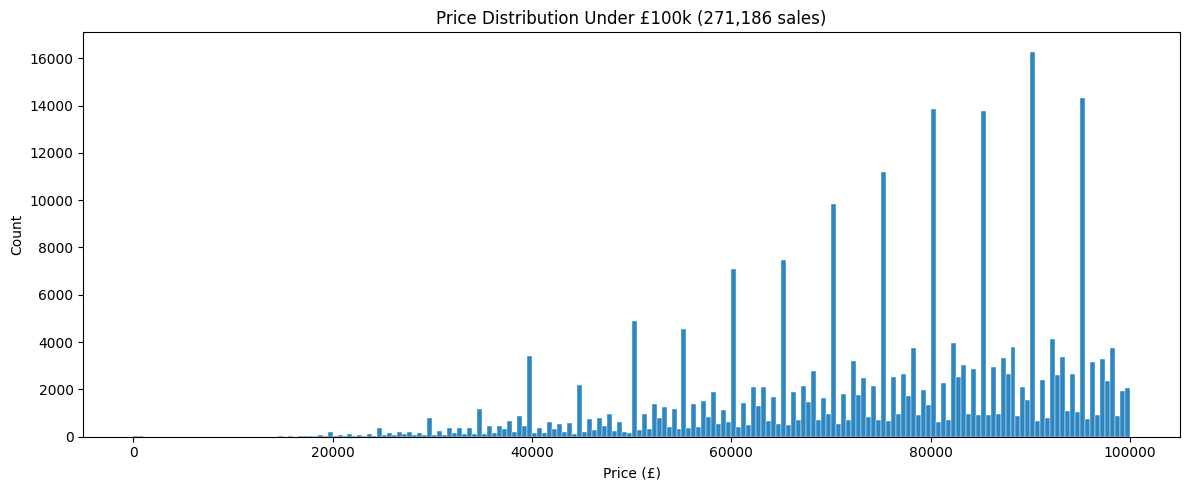

Price bands:
  £0-1,000: 20
  £1,000-5,000: 16
  £5,000-10,000: 14
  £10,000-15,000: 74
  £15,000-20,000: 412
  £20,000-30,000: 2,964
  £30,000-50,000: 25,631
  £50,000-100,000: 267,521


In [11]:
# look at the distribution of prices under £50k
under_100k = df[df["price"] < 100_000]["price"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(under_100k, bins=200, color="#2E86C1", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Price (£)")
ax.set_ylabel("Count")
ax.set_title(f"Price Distribution Under £100k ({len(under_100k):,} sales)")
plt.tight_layout()
plt.show()

# Print counts in small bands
print(f"Price bands:")
for low, high in [(0, 1000), (1000, 5000), (5000, 10000), (10000, 15000), (15000, 20000), (20000, 30000), (30000, 50000), (50000, 100000)]:
    count = df["price"].between(low, high).sum()
    print(f"  £{low:,}-{high:,}: {count:,}")



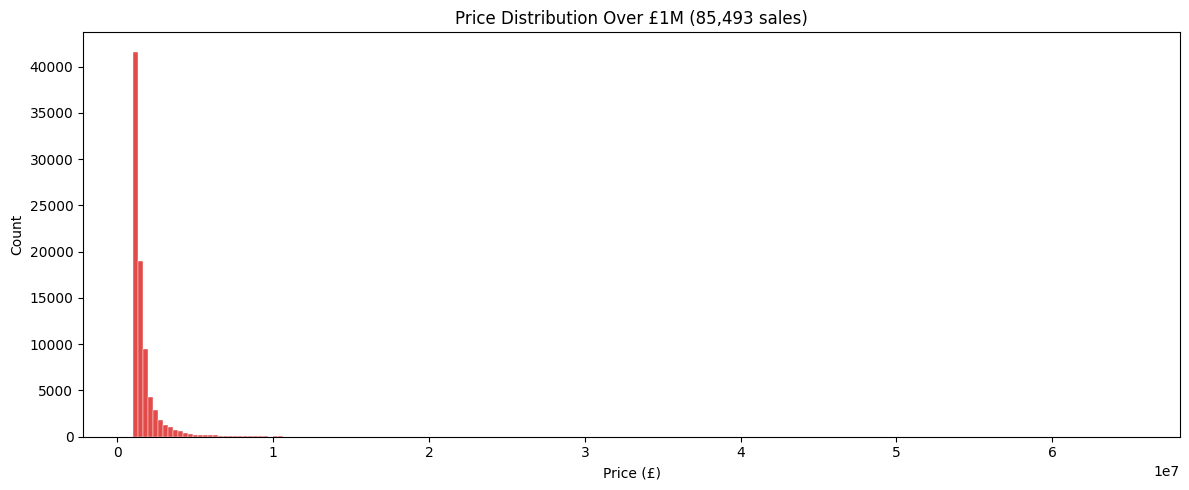

Price bands:
  £1.0M-1.5M: 57,621
  £1.5M-2.0M: 17,669
  £2.0M-3.0M: 9,291
  £3.0M-5.0M: 4,100
  £5.0M-7.5M: 1,156
  £7.5M-10.0M: 402
  £10.0M-20.0M: 324
  £20.0M-50.0M: 84
  £50.0M-100.0M: 4


In [12]:
# Look at the distribution of prices over £1M
over_1m = df[df["price"] > 1_000_000]["price"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(over_1m, bins=200, color="#E24B4A", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Price (£)")
ax.set_ylabel("Count")
ax.set_title(f"Price Distribution Over £1M ({len(over_1m):,} sales)")
plt.tight_layout()
plt.show()

# Print counts in bands
print(f"Price bands:")
for low, high in [(1_000_000, 1_500_000), (1_500_000, 2_000_000), 
                   (2_000_000, 3_000_000), (3_000_000, 5_000_000), 
                   (5_000_000, 7_500_000), (7_500_000, 10_000_000), 
                   (10_000_000, 20_000_000), (20_000_000, 50_000_000),
                   (50_000_000, 100_000_000)]:
    count = df["price"].between(low, high).sum()
    print(f"  £{low/1_000_000:.1f}M-{high/1_000_000:.1f}M: {count:,}")

In [13]:
before = len(df)
df = df[df["price"] >= 10_000]
print(f"Dropped price < £10k: {before:,} → {len(df):,} (removed {before - len(df):,})")

before = len(df)
df = df[df["price"] <= 5_000_000]
print(f"Dropped price > £5M: {before:,} → {len(df):,} (removed {before - len(df):,})")

Dropped price < £10k: 4,300,482 → 4,300,442 (removed 40)
Dropped price > £5M: 4,300,442 → 4,298,586 (removed 1,856)


### Floor area errors

Floor area distribution:
count    4.298586e+06
mean     9.623628e+01
std      4.357757e+01
min      0.000000e+00
25%      7.100000e+01
50%      8.600000e+01
75%      1.100000e+02
max      8.811000e+03
Name: total_floor_area, dtype: float64


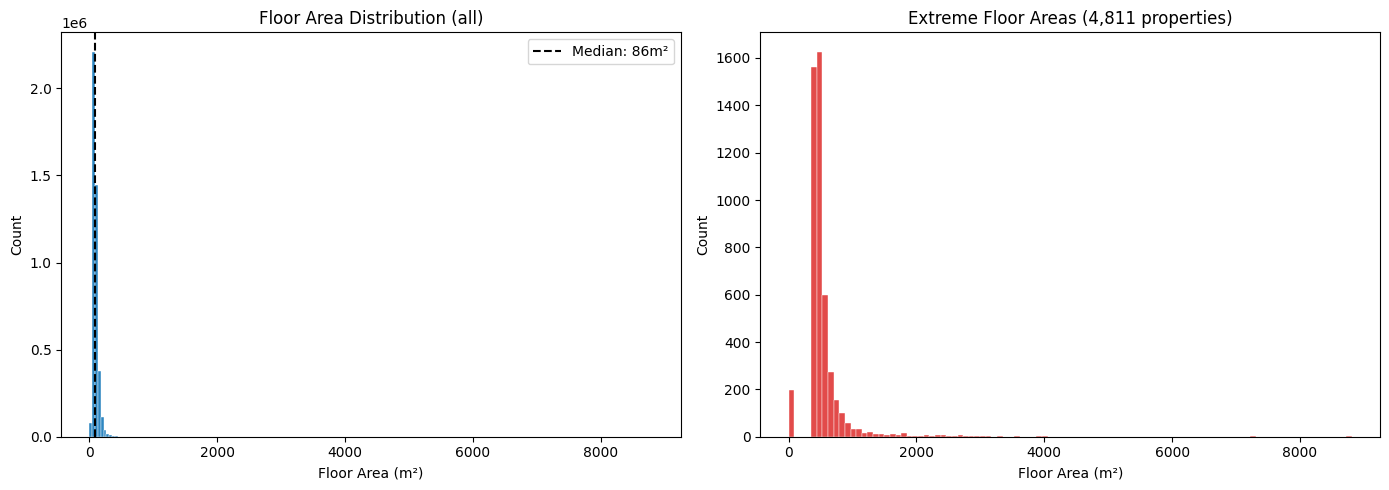


Floor area bands:
  0-5m²: 32
  5-10m²: 87
  10-15m²: 142
  15-30m²: 6,913
  30-50m²: 159,769
  50-100m²: 2,737,155
  100-200m²: 1,349,249
  200-500m²: 109,064
  500-1000m²: 1,533
  1000-10000m²: 227

Under 10m² (90 properties):
           price property_type_x  total_floor_area            built_form
672       375000               F               4.0         Semi-Detached
32720     253250               S               9.0              Detached
35733     190000               S               1.0         Semi-Detached
110812     90000               F               0.0         Semi-Detached
136303    145000               F               9.0         Semi-Detached
168940     68000               F               9.0           End-Terrace
269428    417000               T               7.0           Mid-Terrace
297708    130000               T               2.0         Semi-Detached
454464    145000               S               8.0         Semi-Detached
522415    112000               F        

In [14]:
print(f"Floor area distribution:")
print(df["total_floor_area"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(df["total_floor_area"], bins=200, color="#2E86C1", edgecolor="white", linewidth=0.3)
axes[0].set_title("Floor Area Distribution (all)")
axes[0].set_xlabel("Floor Area (m²)")
axes[0].set_ylabel("Count")
axes[0].axvline(df["total_floor_area"].median(), color="black", linestyle="--", 
                label=f"Median: {df['total_floor_area'].median():.0f}m²")
axes[0].legend()

# Zoom into extremes
extremes = df[(df["total_floor_area"] < 15) | (df["total_floor_area"] > 400)]
axes[1].hist(extremes["total_floor_area"], bins=100, color="#E24B4A", edgecolor="white", linewidth=0.3)
axes[1].set_title(f"Extreme Floor Areas ({len(extremes):,} properties)")
axes[1].set_xlabel("Floor Area (m²)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Bands
print(f"\nFloor area bands:")
for low, high in [(0, 5), (5, 10), (10, 15), (15, 30), (30, 50), 
                   (50, 100), (100, 200), (200, 500), (500, 1000), (1000, 10000)]:
    count = df["total_floor_area"].between(low, high).sum()
    print(f"  {low}-{high}m²: {count:,}")

# What are the tiny ones?
tiny = df[df["total_floor_area"] < 10]
print(f"\nUnder 10m² ({len(tiny):,} properties):")
print(tiny[["price", "property_type_x", "total_floor_area", "built_form"]].to_string())

# What are the huge ones?
huge = df[df["total_floor_area"] > 500]
print(f"\nOver 500m² ({len(huge):,} properties):")
print(huge[["price", "property_type_x", "total_floor_area", "built_form"]].head(20).to_string())

In [15]:
before = len(df)
df = df[(df["total_floor_area"] >= 10) & (df["total_floor_area"] <= 1000)]
print(f"Dropped floor area < 10 or > 1000m²: {before:,} → {len(df):,} (removed {before - len(df):,})")

Dropped floor area < 10 or > 1000m²: 4,298,586 → 4,298,271 (removed 315)


### Duplicate Transactions

In [16]:
# Checking how many transactions are fully duplicated (all columns are the same)
dupes = df.duplicated().sum()
print(f"\n {dupes} fully-duplicated rows.")

group_sizes = df.groupby(list(df.columns),dropna=False).size()
repeat_dist = group_sizes[group_sizes > 1].value_counts().sort_index()
print(repeat_dist)

dupe_rows = df[df.duplicated(keep=False)].sort_values(list(df.columns))
print(f"{len(dupe_rows):,} rows involved in duplication")
print(dupe_rows.head(10).to_string())


 2573 fully-duplicated rows.
2    2481
3      34
4       8
Name: count, dtype: int64
5,096 rows involved in duplication
         price       date property_type_x new_build duration ppd_category postcode_clean  total_floor_area  current_energy_efficiency current_energy_rating  number_habitable_rooms            tenure         construction_age_band   built_form                  main_fuel  exact_lat  exact_lon  comp1_price  comp1_floor_area  comp1_distance_km  comp1_days_ago  comp2_price  comp2_floor_area  comp2_distance_km  comp2_days_ago  comp3_price  comp3_floor_area  comp3_distance_km  comp3_days_ago  has_comparables  dist_primary_km  dist_secondary_km  dist_rail_km  rail_within_1km  rail_within_5km  dist_metro_km  metro_within_1km  dist_airport_km  dist_coast_km  dist_town_km postcode_merged
2050432  19000 2020-01-09               T         N        F            B         DH63QT              71.0                       56.0                     D                     5.0    owner-occupi

In [17]:
# DROPPING FULLY DUPLICATED ROWS
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"{before:,} -> {len(df):,} (dropped {before - len(df):,})")

4,298,271 -> 4,295,698 (dropped 2,573)


In [18]:
# Same property, same price, same date = likely duplicate record
dupes = df.duplicated(subset=["price", "date", "exact_lat", "exact_lon"], keep=False)
print(f"Potential duplicates: {dupes.sum():,} ({dupes.sum()/len(df)*100:.2f}%)")

# Look at them
if dupes.sum() > 0:
    dupe_df = df[dupes].sort_values(["exact_lat", "exact_lon", "date"])
    print(f"\nExamples:")
    print(dupe_df[["price", "date", "property_type_x", "total_floor_area", 
                    "built_form", "exact_lat", "exact_lon"]].head(20).to_string())
    
    # How many unique properties are involved?
    unique_locations = dupe_df.groupby(["exact_lat", "exact_lon"]).size()
    print(f"\nDuplicate groups: {len(unique_locations):,}")
    print(f"Entries per group:")
    print(unique_locations.value_counts().sort_index())
    
    # Are they exact duplicates (all columns same) or just same price/date/location?
    exact_dupes = df.duplicated(keep=False)
    print(f"\nExact row duplicates (all columns): {exact_dupes.sum():,}")

Potential duplicates: 14,981 (0.35%)

Examples:
          price       date property_type_x  total_floor_area     built_form  exact_lat  exact_lon
1304674  615000 2025-01-15               F              85.0    Mid-Terrace  50.138588  -5.086187
1304676  615000 2025-01-15               F              82.0    End-Terrace  50.138588  -5.086187
1839791  135000 2025-12-19               T              63.0    Mid-Terrace  50.159739  -5.077320
1839792  135000 2025-12-19               T              63.0    Mid-Terrace  50.159739  -5.077320
2869927  175000 2021-06-09               S              41.0  Semi-Detached  50.222256  -3.723509
2869931  175000 2021-06-09               S              41.0  Semi-Detached  50.222256  -3.723509
1955982   95000 2025-10-16               F              57.0  Semi-Detached  50.229363  -5.269106
1955983   95000 2025-10-16               F              41.0  Semi-Detached  50.229363  -5.269106
3162395  195000 2021-03-26               T              59.0    Mid-Te

In [19]:
# What property has 114 duplicate entries? ----> ITS A FLAT! 
dupe_df = df[dupes].sort_values(["exact_lat", "exact_lon", "date"])
groups = dupe_df.groupby(["exact_lat", "exact_lon", "price", "date", "property_type_x"]).size()
biggest = groups.sort_values(ascending=False).head(5)
print("Biggest duplicate groups:")
print(biggest)

Biggest duplicate groups:
exact_lat  exact_lon  price   date        property_type_x
52.574206  -0.237935  145000  2022-06-29  F                  11
                      135000  2022-06-29  F                  10
54.699691  -1.182066  168235  2023-04-14  F                   9
54.378002  -1.734640  50663   2022-10-27  F                   9
54.378251  -1.733514  50663   2022-10-27  F                   9
dtype: int64


In [20]:
# Non-flat properties sharing exact coordinates
non_flat = df[df["property_type_x"] != "F"]
location_counts = non_flat.groupby(["exact_lat", "exact_lon", "date", "price"]).size()
shared = location_counts[location_counts > 1]

print(f"Non-flat locations with multiple properties: {len(shared):,} <- the number of groups of non-flat properties that share the same location and date")
print(f"Total properties at shared locations: {shared.sum():,} <- the total number of non-flat properties that share a location and date")
print(f"\nHow many share each location:")
print(shared.value_counts().sort_index())

Non-flat locations with multiple properties: 5,872 <- the number of groups of non-flat properties that share the same location and date
Total properties at shared locations: 11,762 <- the total number of non-flat properties that share a location and date

How many share each location:
2    5855
3      16
4       1
Name: count, dtype: int64


##### NOTE: 
Im only dropping full duplicates across all columns. I looked into dropping rows that share the same price, sale date, and location, but the majority of those turned out to be flats, which legitimately share a coordinate. There are also houses in estates that can have the same location and sale date without being duplicates. That is my justification for keeping rows that only match on some features rather than all of them.

### Energy Efficiency Outliers

count    4.295698e+06
mean     6.633963e+01
std      1.261552e+01
min      1.000000e+00
25%      6.000000e+01
50%      6.700000e+01
75%      7.300000e+01
max      1.610000e+02
Name: current_energy_efficiency, dtype: float64
Missing values: 0


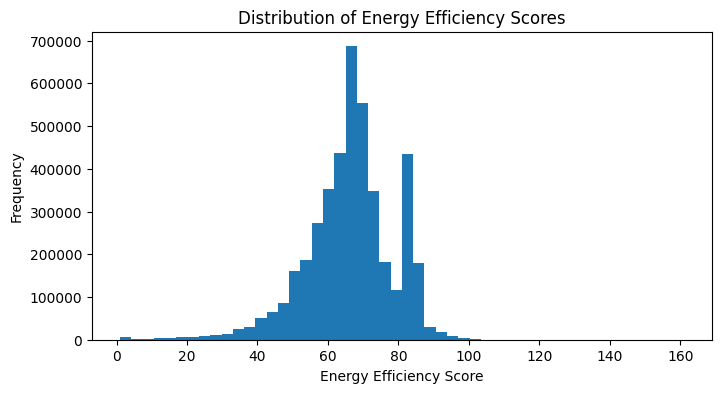

In [21]:
# Summary statistics
print(df["current_energy_efficiency"].describe())

# Check for missing values
print(f"Missing values: {df['current_energy_efficiency'].isna().sum():,}")


# Histogram
plt.figure(figsize=(8, 4))
plt.hist(df["current_energy_efficiency"].dropna(), bins=50)
plt.title("Distribution of Energy Efficiency Scores")
plt.xlabel("Energy Efficiency Score")
plt.ylabel("Frequency")
plt.show()

## Section 4: Clean categories

This section examines all categorical variables for inconsistent labels, duplicate categories (e.g., differences in spelling or capitalisation), infrequent categories, and non-informative values.

In [22]:
categorical_cols = df.select_dtypes(include=["object", "category", "string"]).columns

for col in categorical_cols:
    print(f"\n{'='*70}")
    print(f"{col} ({df[col].nunique()} unique values)")
    print(df[col].value_counts(dropna=False).sort_index())


property_type_x (4 unique values)
property_type_x
D    1093536
F     330829
S    1429377
T    1441956
Name: count, dtype: int64

new_build (2 unique values)
new_build
N    3907518
Y     388180
Name: count, dtype: int64

duration (2 unique values)
duration
F    3725044
L     570654
Name: count, dtype: int64

ppd_category (2 unique values)
ppd_category
A    3860780
B     434918
Name: count, dtype: int64

postcode_clean (882222 unique values)
postcode_clean
AL100AB    4
AL100AE    1
AL100AH    3
AL100AJ    2
AL100AL    1
          ..
YO89XP     7
YO89YA     2
YO89YB     3
YO89YD     1
YO89YE     1
Name: count, Length: 882222, dtype: int64

current_energy_rating (7 unique values)
current_energy_rating
A      26686
B     649851
C    1202916
D    1824845
E     487349
F      79495
G      24556
Name: count, dtype: int64

tenure (8 unique values)
tenure
Owner-occupied       246803
Rented (private)      49304
Rented (social)        6717
Unknown                8095
owner-occupied      2936957
re

In [23]:
print(df["construction_age_band"].dtype)
unique_values = sorted(df["construction_age_band"].dropna().unique())

for value in unique_values:
    print(value)

str
1017
12
1600
17
1750
1800
1805
1842
1848
1849
1850
1855
1860
1870
1880
1889
1890
1895
1899
1900
1905
1910
1915
1920
1925
1929
1930
1933
1935
1939
1940
1949
1950
1955
1960
1962
1964
1965
1967
1968
1970
1972
1974
1980
1983
1987
1988
1989
1990
1994
1995
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
201
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2029
2030
204
2042
206
207
2076
208
2090
2103
2106
2107
2108
213
214
216
2204
5
A
B
C
D
E
England and Wales: 1900-1929
England and Wales: 1930-1949
England and Wales: 1950-1966
England and Wales: 1967-1975
England and Wales: 1976-1982
England and Wales: 1983-1990
England and Wales: 1991-1995
England and Wales: 1996-2002
England and Wales: 2003-2006
England and Wales: 2007 onwards
England and Wales: 2007-2011
England and Wales: 2012 onwards
England and Wales: 2012-2021
England and Wales: 2022 onwards
England and Wales: before 1900
F
G
H
I
J
K
L


In [24]:
# =============================================================================
# CLEAN — CONSTRUCTION AGE
# =============================================================================

# We are creating 3 new columns here. construction year band 1990-2000, exact year 1997, and bool if exact year exists.
# bool is true if exact data was provided nad false if it was taken from range  

# Some EPC records store age bands as RdSAP letter codes (A-L) instead of
# date ranges. These are the official SAP assessment codes defined by BRE.
# Source: https://files.bregroup.com/SAP/RdSAP10-dt13.02.2024.pdf (Table 1)

rdsap_codes = {
    "A": "before 1900", "B": "1900-1929", "C": "1930-1949",
    "D": "1950-1966", "E": "1967-1975", "F": "1976-1982",
    "G": "1983-1990", "H": "1991-1995", "I": "1996-2002",
    "J": "2003-2006", "K": "2007-2011", "L": "2012 onwards",
}

# Representative years are ONLY used when an exact construction year is not
# available. Exact years are always preserved where they exist.

construction_year_map = {
    "before 1900": 1890, "1900-1929": 1915, "1930-1949": 1940,
    "1950-1966": 1958, "1967-1975": 1971, "1976-1982": 1979,
    "1983-1990": 1986, "1991-1995": 1993, "1996-2002": 1999,
    "2003-2006": 2004.5, "2007-2011": 2009, "2012 onwards": 2018,
    "Unknown": np.nan,
}

s = df["construction_age_band"].astype("string").str.strip()
s = s.str.replace("England and Wales: ", "", regex=False)
s = s.replace(rdsap_codes)
s = s.replace({
    "2007 onwards": "2012 onwards",
    "2012-2021": "2012 onwards",
    "2022 onwards": "2012 onwards",
})

# Values that are not correct construction years are treated as Unknown. eg 102, 200, 2204
# Valid exact years are 1600-2026.
numeric_values = pd.to_numeric(s, errors="coerce")
invalid_numeric = (
    numeric_values.notna() &
    ~numeric_values.between(1600, 2026)
)
s.loc[invalid_numeric] = "Unknown"

# Preserve exact four-digit years where available.
# Examples: 1796 -> 1796, 1848 -> 1848, 1952 -> 1952, 2004 -> 2004
exact_year = pd.to_numeric(
    s.where(s.str.fullmatch(r"\d{4}", na=False)),
    errors="coerce"
)

# Sanity check: only accept plausible construction years
exact_year = exact_year.where(exact_year.between(1600, 2026))

def year_to_band(year):
    if pd.isna(year): return pd.NA
    year = int(year)
    if year < 1900: return "before 1900"
    elif year < 1930: return "1900-1929"
    elif year < 1950: return "1930-1949"
    elif year < 1967: return "1950-1966"
    elif year < 1976: return "1967-1975"
    elif year < 1983: return "1976-1982"
    elif year < 1991: return "1983-1990"
    elif year < 1996: return "1991-1995"
    elif year < 2003: return "1996-2002"
    elif year < 2007: return "2003-2006"
    elif year < 2012: return "2007-2011"
    else: return "2012 onwards"


# Generate a band from the exact year where one is available
exact_year_band = exact_year.apply(year_to_band)

# Exact years take priority. Otherwise, retain the cleaned original band.
df["construction_age_band"] = exact_year_band.fillna(s)
# Any remaining missing values become "Unknown"
df["construction_age_band"] = df["construction_age_band"].fillna("Unknown")


# Exact construction years take priority.
df["construction_year"] = exact_year.astype("float64")
# If no exact year exists, use the representative year for the age band.
df["construction_year"] = df["construction_year"].fillna(
    df["construction_age_band"].map(construction_year_map)
)
df["construction_year"] = pd.to_numeric(df["construction_year"], errors="coerce")

# True  = actual construction year was supplied by the EPC
# False = year is estimated from an age band
df["construction_year_exact"] = exact_year.notna()


# check results 
print(f"Number of construction age bands: {df['construction_age_band'].nunique()}")

print("\nConstruction age bands:")
print(df["construction_age_band"].value_counts(dropna=False).sort_index())

print("\nExact construction years:")
print(df["construction_year_exact"].value_counts(dropna=False))
print(f"Construction year NaN: {df['construction_year'].isna().sum():,}")
print("\nConstruction year summary:")
print(df["construction_year"].describe())

print(
    df[
        [
            "construction_age_band",
            "construction_year",
            "construction_year_exact"
        ]
    ].head(20)
)

# dropping the unknown construction age band rows. there is only 68 of them and they are not useful for analysis.
df = df[df["construction_age_band"] != "Unknown"].copy() 

print(f"Rows remaining: {len(df):,}")
print(f"Unknown bands remaining: {(df['construction_age_band'] == 'Unknown').sum():,}")

Number of construction age bands: 13

Construction age bands:
construction_age_band
1900-1929       601545
1930-1949       565858
1950-1966       624548
1967-1975       465055
1976-1982       224868
1983-1990       249386
1991-1995       136927
1996-2002       189757
2003-2006       133969
2007-2011        95757
2012 onwards    687601
Unknown             68
before 1900     320359
Name: count, dtype: int64

Exact construction years:
construction_year_exact
False    3627016
True      668682
Name: count, dtype: int64
Construction year NaN: 68

Construction year summary:
count    4.295630e+06
mean     1.963920e+03
std      3.912894e+01
min      1.600000e+03
25%      1.940000e+03
50%      1.971000e+03
75%      1.999000e+03
max      2.025000e+03
Name: construction_year, dtype: float64
   construction_age_band  construction_year  construction_year_exact
0              1900-1929             1915.0                    False
1            before 1900             1890.0                    False
2  

In [ ]:
df = df.dropna(subset=["construction_age_band"]) #dropping rows since there is only two
print(f"Dropped NaN build age: {before:,} → {len(df):,} (removed {before - len(df):,})")

In [26]:
# =============================================================================
# SECTION 5.2: CLEAN — MAIN FUEL
# =============================================================================

# 48 categories in raw data, many are the same fuel in different formats
# e.g. "mains gas (not community)" and "Gas: mains gas" are both mains gas.
# Grouped by actual fuel type.

def clean_fuel(val):
    if pd.isna(val):
        return val
    val = val.lower()
    if "mains gas" in val or ("gas" in val and "lpg" not in val and "bio" not in val):
        return "mains_gas"
    elif "electric" in val:
        return "electricity"
    elif "oil" in val and "bio" not in val:
        return "oil"
    elif "lpg" in val or "lng" in val:
        return "lpg"
    elif "coal" in val or "anthracite" in val or "smokeless" in val or "dual fuel" in val:
        return "solid_fuel"
    elif ("wood" in val or "biomass" in val or "biogas" in val 
          or "biodiesel" in val or "bioethanol" in val):
        return "biomass"
    else:
        return "other"

df["main_fuel"] = df["main_fuel"].apply(clean_fuel)

print(f"Categories: {df['main_fuel'].nunique()}")
print(df["main_fuel"].value_counts())

Categories: 7
main_fuel
mains_gas      3909230
electricity     233336
oil              92534
lpg              24374
solid_fuel       13148
other             9992
biomass           3029
Name: count, dtype: int64


In [27]:
# =============================================================================
# SECTION 5.3: CLEAN — Tenure + Built Form
# =============================================================================

df["tenure"] = ( df["tenure"].str.strip().str.lower())

print("=" * 60)
print("Tenure (after cleaning)")
print(df["tenure"].value_counts(dropna=False))

df["built_form"] = df["built_form"].replace({
    "Enclosed End-Terrace": "End-Terrace",
    "Enclosed Mid-Terrace": "Mid-Terrace",
    "Not Recorded": "Unknown",
})

print("=" * 60)
print("Built Form (after cleaning)")
print(df["built_form"].value_counts(dropna=False))

Tenure (after cleaning)
tenure
owner-occupied      3183740
unknown              565877
rented (private)     439638
NaN                   65918
rented (social)       40457
Name: count, dtype: int64
Built Form (after cleaning)
built_form
Semi-Detached    1511499
Detached         1153748
Mid-Terrace      1068079
End-Terrace       542181
NaN                18828
Unknown             1295
Name: count, dtype: int64


In [28]:
# see everything is cleaned 

categorical_cols = df.select_dtypes(include=["object", "category", "string"]).columns

for col in categorical_cols:
    print(f"\n{'='*70}")
    print(f"{col} ({df[col].nunique()} unique values)")
    print(df[col].value_counts(dropna=False).sort_index())


property_type_x (4 unique values)
property_type_x
D    1093525
F     330827
S    1429346
T    1441932
Name: count, dtype: int64

new_build (2 unique values)
new_build
N    3907466
Y     388164
Name: count, dtype: int64

duration (2 unique values)
duration
F    3725001
L     570629
Name: count, dtype: int64

ppd_category (2 unique values)
ppd_category
A    3860714
B     434916
Name: count, dtype: int64

postcode_clean (882220 unique values)
postcode_clean
AL100AB    4
AL100AE    1
AL100AH    3
AL100AJ    2
AL100AL    1
          ..
YO89XP     7
YO89YA     2
YO89YB     3
YO89YD     1
YO89YE     1
Name: count, Length: 882220, dtype: int64

current_energy_rating (7 unique values)
current_energy_rating
A      26686
B     649800
C    1202899
D    1824845
E     487349
F      79495
G      24556
Name: count, dtype: int64

tenure (4 unique values)
tenure
owner-occupied      3183740
rented (private)     439638
rented (social)       40457
unknown              565877
NaN                   65918
Na

## Section 5: Fill in missing values.

In [29]:
print("Remaining NaN after filtering and cleaning:\n")
nans = df.isnull().sum()
nans = nans[nans > 0].sort_values(ascending=False)

for col, count in nans.items():
    print(f"  {col}: {count:,} ({count/len(df)*100:.1f}%)")

print(f"\nTotal rows: {len(df):,}")

Remaining NaN after filtering and cleaning:

  number_habitable_rooms: 666,162 (15.5%)
  tenure: 65,918 (1.5%)
  built_form: 18,828 (0.4%)
  main_fuel: 9,987 (0.2%)
  comp3_floor_area: 814 (0.0%)
  comp2_floor_area: 729 (0.0%)
  comp1_floor_area: 640 (0.0%)
  comp3_price: 491 (0.0%)
  comp3_distance_km: 491 (0.0%)
  comp3_days_ago: 491 (0.0%)
  comp2_price: 418 (0.0%)
  comp2_distance_km: 418 (0.0%)
  comp2_days_ago: 418 (0.0%)
  comp1_price: 313 (0.0%)
  comp1_distance_km: 313 (0.0%)
  comp1_days_ago: 313 (0.0%)

Total rows: 4,295,630


### number of rooms 

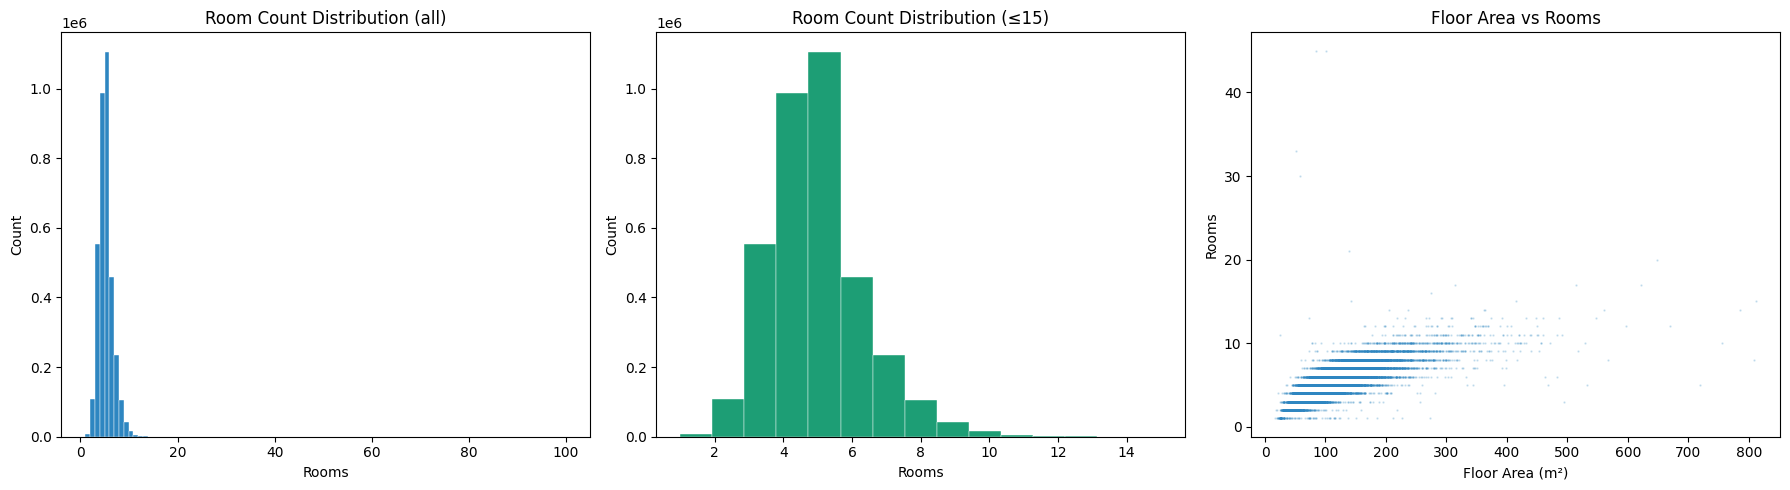

Room counts:
number_habitable_rooms
1.0         7594
2.0       107127
3.0       554195
4.0       987403
5.0      1106269
6.0       459398
7.0       235672
8.0       104622
9.0        41095
10.0       15553
11.0        5712
12.0        2483
13.0         949
14.0         520
15.0         258
16.0         148
17.0          64
18.0          38
19.0          27
20.0          31
21.0          18
22.0          10
23.0           9
24.0           4
25.0           5
26.0           2
27.0           3
28.0           5
30.0          16
31.0           3
32.0           4
33.0          11
34.0           8
35.0           1
36.0           3
38.0           2
39.0           1
40.0          23
41.0          12
42.0           1
43.0           4
44.0          15
45.0          12
46.0           1
47.0           4
49.0           1
50.0          19
51.0          18
52.0           2
53.0           2
54.0          10
55.0          11
56.0           9
58.0           1
60.0          10
61.0           5
63.0        

In [30]:
# =============================================================================
# SECTION 5.1: INVESTIGATE — number_habitable_rooms
# =============================================================================

rooms = df["number_habitable_rooms"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of all room counts
axes[0].hist(rooms, bins=100, color="#2E86C1", edgecolor="white", linewidth=0.3)
axes[0].set_title(f"Room Count Distribution (all)")
axes[0].set_xlabel("Rooms")
axes[0].set_ylabel("Count")

# Zoomed — under 15 rooms (where the real data lives)
axes[1].hist(rooms[rooms <= 15], bins=15, color="#1D9E75", edgecolor="white", linewidth=0.3)
axes[1].set_title(f"Room Count Distribution (≤15)")
axes[1].set_xlabel("Rooms")
axes[1].set_ylabel("Count")

# Rooms vs floor area — does it make sense?
sample = df[df["number_habitable_rooms"].notna()].sample(50000, random_state=42)
axes[2].scatter(sample["total_floor_area"], sample["number_habitable_rooms"], s=0.5, alpha=0.2, color="#2E86C1")
axes[2].set_title("Floor Area vs Rooms")
axes[2].set_xlabel("Floor Area (m²)")
axes[2].set_ylabel("Rooms")

plt.tight_layout()
plt.show()

# Counts by room number
print("Room counts:")
print(rooms.value_counts().sort_index().to_string())

# Suspicious ones — high rooms, small floor area
suspicious = df[(df["number_habitable_rooms"] > 15) & (df["total_floor_area"] < 200)]
print(f"\nSuspicious: >15 rooms but <200m²: {len(suspicious):,}")
print(suspicious[["price", "total_floor_area", "number_habitable_rooms",  "property_type_x", "built_form"]].head(20).to_string())

In [31]:
# =============================================================================
# SECTION 5.1a: CLEAN — room count outliers
# =============================================================================

# Find the threshold from the data — what's the minimum realistic m² per room?
has_both = df["number_habitable_rooms"].notna() & df["total_floor_area"].notna()
m2_per_room = df.loc[has_both, "total_floor_area"] / df.loc[has_both, "number_habitable_rooms"]

threshold = m2_per_room.quantile(0.001)
print(f"1st percentile of m² per room: {threshold:.1f}")
print(f"99% of properties have at least {threshold:.1f}m² per room on average")

# Any property below this threshold has a suspicious room count
bad_ratio = (
    (df["total_floor_area"] / df["number_habitable_rooms"]) < threshold
) & df["number_habitable_rooms"].notna()

print(f"\nProperties below threshold: {bad_ratio.sum():,}")

# Show examples of what we're fixing
if bad_ratio.sum() > 0:
    print(f"\nExamples being fixed:")
    print(df.loc[bad_ratio, ["price", "total_floor_area", "number_habitable_rooms",
                              "property_type_x"]].sort_values("number_habitable_rooms", ascending=False).head(300).to_string())

df.loc[bad_ratio, "number_habitable_rooms"] = np.nan
print(f"\nMax rooms now: {df['number_habitable_rooms'].max():.0f}")

1st percentile of m² per room: 9.5
99% of properties have at least 9.5m² per room on average

Properties below threshold: 3,528

Examples being fixed:
           price  total_floor_area  number_habitable_rooms property_type_x
2915125   140000             111.0                   100.0               T
682425   1090000             166.0                    99.0               D
3942301   377000             115.0                    99.0               S
327973    375000             139.0                    97.0               T
4153876   490000              98.0                    95.0               F
743415    145000              61.0                    94.0               F
2993069   117500              46.0                    92.0               F
2891948   785000             147.0                    90.0               D
1406955   775000             173.0                    90.0               D
1047438   645000             196.0                    88.0               D
1240206   360000        

In [32]:
# =============================================================================
# SECTION 5.1: HANDLE — number_habitable_rooms (15.5% missing)
# =============================================================================

print("number_habitable_rooms:")
print(f"  Missing: {df['number_habitable_rooms'].isna().sum():,}")
print(f"  Max: {df['number_habitable_rooms'].max()}")

# Fill missing based on floor area bins
has_both = df["number_habitable_rooms"].notna() & df["total_floor_area"].notna()
bins = [0, 30, 50, 70, 90, 120, 160, 200, 500, 1000]
df["area_bin"] = pd.cut(df["total_floor_area"], bins=bins)
median_rooms = df.loc[has_both].groupby("area_bin")["number_habitable_rooms"].median()

print(f"\n  Median rooms per floor area:")
for bin_range, rooms in median_rooms.items():
    print(f"    {bin_range}: {rooms:.0f} rooms")

missing = df["number_habitable_rooms"].isna()
df.loc[missing, "number_habitable_rooms"] = df.loc[missing, "area_bin"].map(median_rooms)
df = df.drop(columns=["area_bin"])

print(f"\n  After: {df['number_habitable_rooms'].isna().sum():,} still missing")
print(f"  Max rooms: {df['number_habitable_rooms'].max():.0f}")

number_habitable_rooms:
  Missing: 669,690
  Max: 34.0

  Median rooms per floor area:
    (0, 30]: 1 rooms
    (30, 50]: 2 rooms
    (50, 70]: 3 rooms
    (70, 90]: 4 rooms
    (90, 120]: 5 rooms
    (120, 160]: 6 rooms
    (160, 200]: 7 rooms
    (200, 500]: 8 rooms
    (500, 1000]: 11 rooms

  After: 0 still missing
  Max rooms: 34


In [33]:
# check after cleaning and filling missing values

rooms = df["number_habitable_rooms"].dropna()

# Counts by room number
print("Room counts:")
print(rooms.value_counts().sort_index().to_string())

# Suspicious ones — high rooms, small floor area
suspicious = df[(df["number_habitable_rooms"] > 15) & (df["total_floor_area"] < 200)]
print(f"\nSuspicious: >15 rooms but <200m²: {len(suspicious):,}")
print(suspicious[["price", "total_floor_area", "number_habitable_rooms", 
                   "property_type_x", "built_form"]].head(50).to_string())

suspicious = df[(df["number_habitable_rooms"] > 15)]
print(f"\nAnything with >15 rooms: {len(suspicious):,}")
print(suspicious[["price", "total_floor_area", "number_habitable_rooms", 
                   "property_type_x", "built_form"]].to_string())

Room counts:
number_habitable_rooms
1.0        8414
2.0      117103
3.0      650789
4.0     1175401
5.0     1310672
6.0      579345
7.0      267632
8.0      119771
9.0       40955
10.0      15431
11.0       5816
12.0       2414
13.0        916
14.0        473
15.0        232
16.0        131
17.0         55
18.0         23
19.0         18
20.0         19
21.0         10
22.0          3
23.0          2
25.0          1
27.0          1
28.0          1
34.0          2

Suspicious: >15 rooms but <200m²: 13
           price  total_floor_area  number_habitable_rooms property_type_x     built_form
443186    685000             187.0                    19.0               D       Detached
736665    720000             155.0                    16.0               D       Detached
1735987   490000             191.0                    17.0               T    End-Terrace
1957463   162500             177.0                    17.0               T    Mid-Terrace
2104117   390000             179.0          

### tenure

In [34]:
df["tenure"] = df["tenure"].fillna("unknown")

### built_form

In [35]:
df["built_form"] = df["built_form"].fillna("Unknown")

### main_fuel

In [36]:
df["main_fuel"] = df["main_fuel"].fillna("unknown")

### construction_age_band

In [37]:
df = df.dropna(subset=["construction_age_band"]) #dropping rows since there is only two

### property_type_x

In [38]:
df["property_type_x"] = df["property_type_x"].fillna("unknown")

postcodes

In [39]:
postcodes = pd.read_csv(
    "Data/Online_ONS_Postcode_Directory_Live.csv",
    usecols=["PCDS", "LAT", "LONG"]
)
postcodes["PCDS"] = postcodes["PCDS"].str.strip().str.upper()
postcodes.loc[postcodes["LAT"] == 99.999999, "LAT"] = None
postcodes.loc[postcodes["LONG"] == 0.0, "LONG"] = None
ref = postcodes.dropna(subset=["LAT", "LONG"])

# 3. Anything still missing but with coordinates -> nearest postcode centroid
tree = BallTree(np.deg2rad(ref[["LAT", "LONG"]].values), metric="haversine")
need = df["postcode_merged"].isna() & df["exact_lat"].notna() & df["exact_lon"].notna()

if need.sum():
    _, idx = tree.query(np.deg2rad(df.loc[need, ["exact_lat", "exact_lon"]].values), k=1)
    df.loc[need, "postcode_merged"] = ref["PCDS"].values[idx.flatten()]

print(f"Filled. Remaining missing: {df['postcode_merged'].isna().sum():,}")

Filled. Remaining missing: 0


## Feature engineering

In [40]:
df["postcode_area"] = df["postcode_merged"].str.split().str[0]
tmp = df[["postcode_area", "price", "date"]].sort_values("date")
logp = np.log1p(tmp["price"])
tmp["area_past_price"] = (
    logp.groupby(tmp["postcode_area"])
        .apply(lambda s: s.shift(1).expanding().median())
        .reset_index(level=0, drop=True)
)
# assign back to df by index — df keeps its original order
df["area_past_price"] = tmp["area_past_price"]

df = df.drop(columns=["postcode_area"])
df = df.drop(columns=["postcode_merged"])

before = len(df)
df = df.dropna(subset=[
    "area_past_price","comp1_floor_area", "comp2_floor_area", "comp3_floor_area",
]).reset_index(drop=True)
print(f"Dropped rows with missing area/comp floor: {before:,} → {len(df):,} (removed {before - len(df):,})")


Dropped rows with missing area/comp floor: 4,295,630 → 4,291,929 (removed 3,701)


In [41]:
#property_age

sale_year = pd.to_datetime(df["date"], errors="coerce").dt.year

# Calculate property age at sale
df["property_age"] = sale_year - df["construction_year"]

print(df["property_age"].describe())
print(f"\nNaN count: {df['property_age'].isna().sum():,}")
print(f"NaN percentage: {df['property_age'].isna().mean() * 100:.2f}%")

count    4.291929e+06
mean     5.851212e+01
std      3.919178e+01
min     -4.000000e+00
25%      2.500000e+01
50%      5.400000e+01
75%      8.400000e+01
max      4.220000e+02
Name: property_age, dtype: float64

NaN count: 0
NaN percentage: 0.00%


In [42]:
# Number of months since the first transaction
df["sale_time"] = (
    (df["date"].dt.year - df["date"].dt.year.min()) * 12
    + (df["date"].dt.month - 1)
)

print(f"Sale time: {df['sale_time'].min()} — {df['sale_time'].max()} months")

# Drop original date column
df = df.drop(columns=["date"])

Sale time: 0 — 71 months


In [43]:
# Removing day of the year caused some duplicates, so we need to check for duplicates again and remove them
print(f"full_dupes={df.duplicated().sum():,} | rows={len(df):,}")

print(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(4).to_string())

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"{before:,} -> {len(df):,} (dropped {before - len(df):,})")

full_dupes=1 | rows=4,291,929
          price property_type_x new_build duration ppd_category postcode_clean  total_floor_area  current_energy_efficiency current_energy_rating  number_habitable_rooms   tenure construction_age_band     built_form  main_fuel  exact_lat  exact_lon  comp1_price  comp1_floor_area  comp1_distance_km  comp1_days_ago  comp2_price  comp2_floor_area  comp2_distance_km  comp2_days_ago  comp3_price  comp3_floor_area  comp3_distance_km  comp3_days_ago  has_comparables  dist_primary_km  dist_secondary_km  dist_rail_km  rail_within_1km  rail_within_5km  dist_metro_km  metro_within_1km  dist_airport_km  dist_coast_km  dist_town_km  construction_year  construction_year_exact  area_past_price  property_age  sale_time
144840   309000               S         N        F            A         ME12QH              84.0                       84.0                     B                     4.0  unknown          2012 onwards  Semi-Detached  mains_gas  51.372608   0.513352     3400

In [44]:
distance_cols = [
    "dist_primary_km",
    "dist_secondary_km",
    "dist_rail_km",
    "dist_metro_km",
    "dist_airport_km",
    "dist_coast_km",
    "dist_town_km",
]

for col in distance_cols:
    df[col] = np.log1p(df[col])

In [45]:
comp_to_log_cols = ["comp1_price", "comp2_price", "comp3_price", "comp3_distance_km", "comp2_distance_km", "comp1_distance_km"]
for c in comp_to_log_cols:
    df[c] = np.log1p(df[c])

## Final check and Save

In [46]:
# =============================================================================
# Final Data Quality Checks
# =============================================================================

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

print("\nData types:")
print(df.dtypes)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(3)

missing_summary = (
    pd.DataFrame({
        "Missing": missing,
        "Percent": missing_pct
    })
    .query("Missing > 0")
    .sort_values("Missing", ascending=False)
)

print(missing_summary)

print("\n" + "=" * 70)
print("DUPLICATES")
print("=" * 70)

duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicates:,}")

print("\n" + "=" * 70)
print("NUMERIC SUMMARY")
print("=" * 70)

print(df.describe())

print("\n" + "=" * 70)
print("CATEGORICAL SUMMARY")
print("=" * 70)

categorical_cols = df.select_dtypes(include=["object", "category", "string"]).columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))

DATASET OVERVIEW
Rows: 4,291,928
Columns: 44

Data types:
price                          int64
property_type_x                  str
new_build                        str
duration                         str
ppd_category                     str
postcode_clean                   str
total_floor_area             float64
current_energy_efficiency    float64
current_energy_rating            str
number_habitable_rooms       float64
tenure                           str
construction_age_band            str
built_form                       str
main_fuel                        str
exact_lat                    float64
exact_lon                    float64
comp1_price                  float64
comp1_floor_area             float64
comp1_distance_km            float64
comp1_days_ago               float64
comp2_price                  float64
comp2_floor_area             float64
comp2_distance_km            float64
comp2_days_ago               float64
comp3_price                  float64
comp3_floor_area 

In [47]:
df.to_parquet( "Outputs/clean_property_data.parquet", index=False,compression="snappy")

print("Dataset successfully saved.")

Dataset successfully saved.
